# Typhoon Nanmadol Track — flash-aurora Engine

Same setup as the upstream [Microsoft Aurora TC tracking example](microsoft-aurora/docs/example_tc_tracking.ipynb):

- **Date:** 2022-09-17
- **Initial condition:** 12:00 UTC (history 06:00 + 12:00 via `TIME_INDEX=2`)
- **Rollout:** 8 steps (~48 h)
- **Model:** `aurora-0.25-finetuned` via preset `tc_tracking`

Uses the same HRES T0 ingress as `hres_t0_finetuned`, but **`TIME_INDEX=2`** selects the third synoptic time as IC (matching upstream `_prepare` with `x[[1,2]]`).

After each step we call **`Tracker.step(pred)`** from `flash_aurora.aurora` to estimate typhoon center from MSL pressure.


In [1]:
from datetime import datetime
from pathlib import Path

from flash_aurora.engine import (
    AuroraEngine,
    DataDownloader,
    DEFAULT_PRESETS,
    HF_MIRROR_ENDPOINT,
    InitialConditionBuilder,
)
from flash_aurora.engine.core.redaction import safe_path

PRESET = "tc_tracking"
VALID_TIME = datetime(2022, 9, 17, 12)
TIME_INDEX = 2
ROLLOUT_STEPS = 8

# Named tier or combo: backbone@encoder_decoder (see README).
INFERENCE_PRECISION = "bf16_mixed@fp32"

# Default: ./assets under the notebook working directory (created if missing).
ASSET_ROOT: Path | str | None = None

# Optional — absolute path to a mounted data disk with checkpoints/cache (uncomment to use):
ASSET_ROOT = Path("/root/autodl-tmp/aurora")

if ASSET_ROOT is not None:
    root = Path(ASSET_ROOT).expanduser()
    if not root.is_absolute():
        raise ValueError("ASSET_ROOT must be an absolute path")
    ASSET_ROOT = root.resolve()
else:
    ASSET_ROOT = (Path.cwd() / "assets").resolve()
    ASSET_ROOT.mkdir(parents=True, exist_ok=True)

USE_HF_MIRROR = False
variant = DEFAULT_PRESETS.get(PRESET).variant
local_checkpoint = ASSET_ROOT / variant.checkpoint_filename

if local_checkpoint.is_file():
    checkpoint_arg = local_checkpoint
    allow_hub_download = False
    hf_endpoint = None
    print("checkpoint:", safe_path(local_checkpoint))
else:
    checkpoint_arg = None
    allow_hub_download = True
    hf_endpoint = HF_MIRROR_ENDPOINT if USE_HF_MIRROR else None
    print("checkpoint not found locally; will download from Hugging Face")
    print("  target dir:", safe_path(ASSET_ROOT))
    print("  hf_endpoint:", hf_endpoint or "https://huggingface.co")

downloader = DataDownloader.from_preset(PRESET, asset_root=ASSET_ROOT)
engine = AuroraEngine.from_preset(
    PRESET,
    asset_root=ASSET_ROOT,
    checkpoint_path=checkpoint_arg,
    allow_hub_download=allow_hub_download,
    hf_endpoint=hf_endpoint,
    inference_precision=INFERENCE_PRECISION,
)

print("cache_dir:", safe_path(downloader.resolve_cache_dir()))
print("asset_root:", safe_path(ASSET_ROOT))


/root/flash-aurora/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


checkpoint: ~/autodl-tmp/aurora/aurora-0.25-finetuned.ckpt
cache_dir: ~/autodl-tmp/aurora/hres_t0
asset_root: ~/autodl-tmp/aurora


## 1. Download HRES T0 + ERA5 static

Identical cache layout to [example_hres_t0.ipynb](example_hres_t0.ipynb) under `<ASSET_ROOT>/hres_t0/`.


In [2]:
import getpass
import os

missing_files = downloader.missing(VALID_TIME)
cds_api_key = None

if missing_files:
    cds_api_key = os.environ.get("CDSAPI_KEY", "").strip() or None
    if cds_api_key is None and not Path.home().joinpath(".cdsapirc").is_file():
        cds_api_key = getpass.getpass("CDS API key (ERA5 static): ").strip() or None
    if not cds_api_key and not Path.home().joinpath(".cdsapirc").is_file():
        raise ValueError("CDS credentials required for static.nc")
    print("Downloading missing cache files:", missing_files)

result = downloader.ensure(VALID_TIME, cds_api_key=cds_api_key)
print("downloaded:", result.downloaded)
print("skipped:", result.skipped)
for key, path in result.paths.items():
    print(f"  {key}: {safe_path(path)}")


downloaded: ()
skipped: ('static', 'surface', 'atmospheric')
  static: ~/autodl-tmp/aurora/hres_t0/static.nc
  surface: ~/autodl-tmp/aurora/hres_t0/2022-09-17-surface-level.nc
  atmospheric: ~/autodl-tmp/aurora/hres_t0/2022-09-17-atmospheric.nc


## 2–3. Build IC, load model, rollout with Tracker

Nanmadol position at 2022-09-17 12:00 UTC from IBTrACS (upstream notebook). We stream rollout steps and update the tracker after each prediction — same control flow as upstream, but via `engine.rollout_stream()`.


In [3]:
import torch

from flash_aurora.aurora import Tracker
from flash_aurora.aurora.model.inference_precision import describe_inference_config

tracker = Tracker(
    init_lat=27.50,
    init_lon=132,
    init_time=datetime(2022, 9, 17, 12, 0),
)

request = downloader.ingest_request(VALID_TIME, time_index=TIME_INDEX, download=False)
batch = InitialConditionBuilder(engine.config).from_source(request)
print("IC time:", batch.metadata.time)

engine.load(rollout_steps=ROLLOUT_STEPS)
print("device:", next(engine.model.parameters()).device)

cfg = engine.model.inference_config
if cfg is not None:
    print("inference tier:", cfg.config_label)
    print(describe_inference_config(cfg))

preds = []
with torch.inference_mode():
    for pred in engine.rollout_stream(batch, ROLLOUT_STEPS):
        pred = pred.to("cpu")
        preds.append(pred)
        tracker.step(pred)

print("track points:", len(tracker.results()))


IC time: (datetime.datetime(2022, 9, 17, 12, 0),)
device: cuda:0
inference tier: bf16_mixed@fp32
backbone matmul hybrid: BF16 attention QKV/proj + BF16 MLP; TF32 elsewhere; encoder/decoder matmul FP32 (native Perceiver SDPA); Triton layout+AdaLN; CuTe window attention (bfloat16); backbone activations float32
track points: 9


## 4. Visualize MSL and track

Eight panels around the West Pacific; black dots = full track, red dot = current step (upstream layout).


<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:38: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:38: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_201485/2503059999.py:30: SyntaxWarning: invalid escape sequence '\c'
  f"Lat.: {this_step.lat.iloc[0]:.1f}$^\circ$",
/tmp/ipykernel_201485/2503059999.py:38: SyntaxWarning: invalid escape sequence '\c'
  f"Lon.: {this_step.lon.iloc[0]:.1f}$^\circ$",


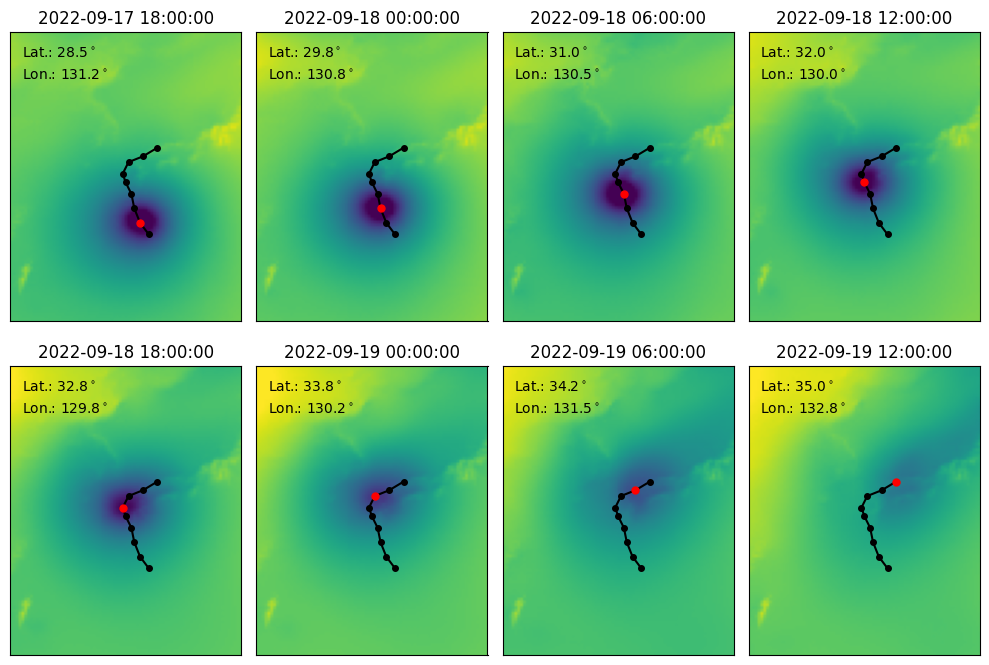

In [4]:
import matplotlib.pyplot as plt

track = tracker.results()

fig, axs = plt.subplots(2, 4, figsize=(10, 7))

for i in range(8):
    pred = preds[i]
    ax = axs[i // 4, i % 4]

    lat_mask = (pred.metadata.lat >= 20) & (pred.metadata.lat <= 45)
    lon_mask = (pred.metadata.lon >= 120) & (pred.metadata.lon <= 140)

    ax.imshow(
        pred.surf_vars["msl"][0, 0][lat_mask][:, lon_mask].numpy() / 100,
        vmin=970,
        vmax=1020,
        extent=(120, 140, 20, 45),
    )
    ax.set_title(str(pred.metadata.time[0]))
    ax.set_xticks([])
    ax.set_yticks([])

    ax.plot(track.lon, track.lat, c="k", marker=".", markersize=8)
    this_step = track[track.time == pred.metadata.time[0]]
    ax.plot(this_step.lon, this_step.lat, c="r", marker=".", markersize=10)
    ax.text(
        0.05,
        0.95,
        f"Lat.: {this_step.lat.iloc[0]:.1f}$^\circ$",
        ha="left",
        va="top",
        transform=ax.transAxes,
    )
    ax.text(
        0.05,
        0.875,
        f"Lon.: {this_step.lon.iloc[0]:.1f}$^\circ$",
        ha="left",
        va="top",
        transform=ax.transAxes,
    )

plt.tight_layout()
plt.show()


In [5]:
engine.release_gpu()
del engine